In [4]:
import pandas as pd
import configparser
import os
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', 500)
pd.set_option('display.max_rows', 50)

In [5]:
uri = "bolt://localhost:7687"
username = "neo4j"
password = "12345678" 

In [6]:
from graphdatascience import GraphDataScience

# Use Neo4j URI and credentials according to your setup
gds = GraphDataScience(uri, auth=(username, password))

In [7]:
def check_gds_connection(uri, username, password):
    try:
        # Kiểm tra xem graphdatascience đã được cài chưa
        import graphdatascience
        from graphdatascience import GraphDataScience

        print("✅ Thư viện 'graphdatascience' đã được cài đặt thành công.")

        # Kết nối tới Neo4j
        gds = GraphDataScience(uri, auth=(username, password))

        # Kiểm tra phiên bản để xác minh kết nối
        version = gds.version()
        print(f"✅ Đã kết nối tới Neo4j. Phiên bản GDS: {version}")

        return gds

    except ImportError:
        print("❌ Thư viện 'graphdatascience' chưa được cài đặt. Vui lòng cài đặt bằng lệnh:")
        print("python -m pip install graphdatascience")

    except Exception as e:
        print(f"❌ Lỗi khi kết nối với Neo4j: {e}")

# Thông tin kết nối của bạn
uri = "bolt://localhost:7687"   # Hoặc thay đổi nếu cổng khác
username = "neo4j"              # Tên đăng nhập của Neo4j
password = "12345678"      # Mật khẩu của Neo4j

# Gọi hàm để kiểm tra
check_gds_connection(uri, username, password)


✅ Thư viện 'graphdatascience' đã được cài đặt thành công.
✅ Đã kết nối tới Neo4j. Phiên bản GDS: 2.26.0


In [8]:
def clear_graph_by_name(g_name):
    if gds.graph.exists(g_name).exists:
        g = gds.graph.get(g_name)
        gds.graph.drop(g)

def clear_all_graphs():
    g_names = gds.graph.list().graphName.tolist()
    for g_name in g_names:
        g = gds.graph.get(g_name)
        gds.graph.drop(g)

def identifier_degrees(user_label, degree_property):
    g_name = 'id-projection'
    clear_graph_by_name(g_name)
    g, _  = gds.graph.project(g_name, [user_label, 'Card', 'Device', 'IP'],{
        'HAS_CC': {'orientation': 'REVERSE'},
        'HAS_IP': {'orientation': 'REVERSE'},
        'USED': {'orientation': 'REVERSE'}
    })
    gds.degree.mutate(g, mutateProperty=degree_property)
    gds.graph.writeNodeProperties(g, [degree_property], ['Card', 'Device', 'IP'])
    g.drop()

In [9]:
gds.run_cypher('''
    CALL apoc.meta.stats()
    YIELD labels
    UNWIND keys(labels) AS nodeLabel
    RETURN nodeLabel, labels[nodeLabel] AS nodeCount
''')

,nodeLabel,nodeCount
0,User,33732
1,Device,51451
2,Card,118818
3,IP,585855


In [10]:
gds.run_cypher('''
    CALL apoc.meta.stats()
    YIELD relTypesCount
    UNWIND keys(relTypesCount) AS relationshipType
    RETURN relationshipType, relTypesCount[relationshipType] AS relationshipCount
''')

,relationshipType,relationshipCount
0,USED,55026
1,HAS_IP,1488949
2,HAS_CC,128066
3,REFERRED,1870
4,P2P,102832


In [11]:
gds.run_cypher('MATCH(u:User) RETURN u.fraudMoneyTransfer AS fraudMoneyTransfer, count(u) AS cnt')

,fraudMoneyTransfer,cnt
0,0,33491
1,1,241


In [12]:
gds.run_cypher('MATCH(u:User) WHERE u.fraudMoneyTransfer=1 SET u:FlaggedUser RETURN count(u)')

,count(u)
0,241


In [13]:
identifier_degrees('User', 'degree')
identifier_degrees('FlaggedUser', 'flaggedDegree')

gds.run_cypher('''
    MATCH(n) WHERE n:Card OR n:Device OR n:IP
    SET n.flaggedRatio = toFloat(n.flaggedDegree)/toFloat(n.degree)
''')

""


In [14]:
print('Flagged User Ratio for Card Count')
gds.run_cypher('''
    MATCH(n:Card) WHERE n.degree > 1
    WITH COUNT(n) AS total
    MATCH(n:Card) WHERE n.degree > 1
    WITH n, total, CASE
    WHEN n.flaggedRatio=0 THEN '0'
    WHEN n.flaggedRatio=1 THEN '1'
    ELSE 'Between 0-1' END AS flaggedUserRatio
    WITH flaggedUserRatio, total, COUNT(n) AS count
    RETURN flaggedUserRatio, count, round(toFloat(count)/total, 3) AS percentCount
    ORDER BY flaggedUserRatio
''')

Flagged User Ratio for Card Count


,flaggedUserRatio,count,percentCount
0,0,8185,0.964
1,1,31,0.004
2,Between 0-1,274,0.032


In [15]:
print('Flagged User Ratio for Device Count')
gds.run_cypher('''
    MATCH(n:Device) WHERE n.degree > 1
    WITH COUNT(n) AS total
    MATCH(n:Device) WHERE n.degree > 1
    WITH n, total, CASE
    WHEN n.flaggedRatio=0 THEN '0'
    WHEN n.flaggedRatio=1 THEN '1'
    ELSE 'Between 0-1' END AS flaggedUserRatio
    WITH flaggedUserRatio, total, COUNT(n) AS count
    RETURN flaggedUserRatio, count, round(toFloat(count)/total, 3) AS percentCount
    ORDER BY flaggedUserRatio
''')

Flagged User Ratio for Device Count


,flaggedUserRatio,count,percentCount
0,0,2655,0.967
1,1,2,0.001
2,Between 0-1,88,0.032


In [16]:
clear_graph_by_name('comm-projection')

g, _ = gds.graph.project('comm-projection', ['User','Card', 'Device'], {
    'HAS_CC': {'orientation': 'UNDIRECTED'},
    'USED': {'orientation': 'UNDIRECTED'},
    'P2P': {'orientation': 'NATURAL', 'aggregation': 'SINGLE'}
})

df = gds.louvain.write(g, writeProperty='louvainCommunityId')
g.drop()
df

 Louvain:   4%|4         | 4.07/100 [00:00<?, ?%/s]

modularity                                                                                                                                                                                                                                                                                                                                                                                                             0.980952
modularities                                                                                                                                                                                                           [0.8467651406674878, 0.9587732914858469, 0.9745165497020519, 0.9783278174630614, 0.9795827822484974, 0.9801502456855288, 0.9804397771900464, 0.9806363801576393, 0.9808158922450229, 0.9809516898602914]
ranLevels                                                                                                                                                               

In [17]:
print("Louvain Communities Ordered by count of Flagged Users")
gds.run_cypher('''
    MATCH (u:User)
    WITH u.louvainCommunityId AS community,
        count(u) AS cnt,
        sum(u.fraudMoneyTransfer) as flaggedCount
    RETURN community,
        cnt,
        flaggedCount,
        toFloat(flaggedCount)/toFloat(cnt) AS flaggedRatio
    ORDER BY flaggedCount DESC LIMIT 100
''')


Louvain Communities Ordered by count of Flagged Users


,community,cnt,flaggedCount,flaggedRatio
0,25771,149,7,0.046980
1,182733,7,4,0.571429
2,56371,889,3,0.003375
3,176956,3,3,1.000000
4,173038,240,3,0.012500
...,...,...,...,...
95,5799,4,1,0.250000
96,181758,61,1,0.016393
97,174011,20,1,0.050000
98,173401,5,1,0.200000


In [18]:
gds.run_cypher('''
    MATCH (u1:User)-[r:P2P]->(u2)
    WITH u1, u2, count(r) AS cnt
    MATCH (u1)-[:HAS_CC]->(n)<-[:HAS_CC]-(u2)
    WITH u1, u2, count(DISTINCT n) AS cnt
    MERGE(u1)-[s:P2P_WITH_SHARED_CARD]->(u2)
    RETURN count(DISTINCT s) AS cnt
''')

,cnt
0,6240


In [19]:
gds.run_cypher('''
    MATCH (u1:User)-[:HAS_CC|USED]->(n)<-[:HAS_CC|USED]-(u2)
    WHERE n.degree <= 10 AND id(u1) < id(u2) 
    WITH u1, u2, count(DISTINCT n) as cnt
    MATCH (u1)-[:HAS_CC|USED|HAS_IP]->(m)<-[:HAS_CC|USED|HAS_IP]-(u2)
    WITH u1, u2, count(DISTINCT m) as cnt
    WHERE cnt > 2
    MERGE(u1)-[s:SHARED_IDS]->(u2)
    RETURN count(DISTINCT s)
''')

,count(DISTINCT s)
0,5316


In [20]:
clear_graph_by_name('comm-projection')

g, _ = gds.graph.project('comm-projection', ['User'], {
    'SHARED_IDS': {'orientation': 'UNDIRECTED'},
    'P2P_WITH_SHARED_CARD': {'orientation': 'UNDIRECTED'}
})
df = gds.wcc.write(g, writeProperty='wccId')
g.drop()
df

componentCount                                                                                                                                                                                                                                                                                                             28203
componentDistribution                                                                                                                                                       {'p1': 1, 'p5': 1, 'max': 175, 'p90': 2, 'p50': 1, 'p95': 2, 'p10': 1, 'p75': 1, 'p99': 3, 'p25': 1, 'min': 1, 'mean': 1.196042974151686, 'p999': 8}
preProcessingMillis                                                                                                                                                                                                                                                                                                            0
computeMillis                        

In [21]:
gds.run_cypher('''
    MATCH (f:FlaggedUser)
    WITH collect(DISTINCT f.wccId) AS flaggedCommunities
    MATCH(u:User) WHERE u.wccId IN flaggedCommunities
    SET u:FraudRiskUser
    SET u.fraudRisk=1
    RETURN count(u)
''')

,count(u)
0,452


In [22]:
gds.run_cypher('''
    MATCH (u:User) WHERE NOT u:FraudRiskUser
    SET u.fraudRisk=0
    RETURN count(u)
''')

,count(u)
0,33280


In [23]:
gds.run_cypher( '''
    MATCH (u:User)
    WITH u.wccId AS community, count(u) AS cSize, sum(u.fraudRisk) AS cFraudSize
    WITH community, cSize, cFraudSize,
    CASE
        WHEN cSize=1 THEN ' 1'
        WHEN cSize=2 THEN ' 2'
        WHEN cSize=3 THEN ' 3'
        WHEN cSize>3 AND cSize<=10 THEN ' 4-10'
        WHEN cSize>10 AND cSize<=50 THEN '11-50'
        WHEN cSize>10 THEN '>50' END AS componentSize
    RETURN componentSize, 
        count(*) AS numberOfComponents, 
        sum(cSize) AS totalUserCount, 
        sum(cFraudSize) AS fraudUserCount 
    ORDER BY componentSize
''')

,componentSize,numberOfComponents,totalUserCount,fraudUserCount
0,1,24283,24283,118
1,2,3165,6330,144
2,3,481,1443,63
3,4-10,258,1246,68
4,11-50,15,255,59
5,>50,1,175,0


In [24]:
gds.run_cypher('''
   MATCH (:FlaggedUser)-[r:P2P]-(u)  WHERE NOT u:FlaggedUser
   WITH toFloat(sum(r.totalAmount)) AS p2pTotal
   MATCH (u:FraudRiskUser)-[r:P2P]-(:FlaggedUser) WHERE NOT u:FlaggedUser
   WITH p2pTotal,  toFloat(sum(r.totalAmount)) AS fraudRiskP2pTotal
   RETURN round((fraudRiskP2pTotal)/p2pTotal,3) AS p
''').p[0]

0.652

In [25]:
gds.run_cypher('''
   MATCH (:User)-[r:P2P]->()
   WITH toFloat(sum(r.totalAmount)) AS p2pTotal
   MATCH (u:FraudRiskUser)-[r:P2P]-() WHERE NOT u:FlaggedUser
   WITH p2pTotal, toFloat(sum(r.totalAmount)) AS fraudRiskP2pTotal
   RETURN round((fraudRiskP2pTotal)/p2pTotal,3) AS p
''').p[0]

0.127

In [26]:
identifier_degrees('FraudRiskUser', 'fraudRiskDegree')

gds.run_cypher('''
    MATCH(n) WHERE n:Card OR n:Device OR n:IP
    SET n.fraudRiskRatio = toFloat(n.fraudRiskDegree)/toFloat(n.degree)
''')

""


In [27]:
gds.run_cypher('''
    MATCH(n:Card) WHERE n.degree > 1
    WITH COUNT(n) AS total
    MATCH(n:Card) WHERE n.degree > 1
    WITH n, total, CASE
    WHEN n.fraudRiskRatio=0 THEN '0'
    WHEN n.fraudRiskRatio=1 THEN '1'
    ELSE 'Between 0-1' END AS fraudRiskRatio
    WITH fraudRiskRatio, total, COUNT(n) AS count
    RETURN fraudRiskRatio, count, round(toFloat(count)/total, 3) AS percentCount
    ORDER BY fraudRiskRatio
''')

,fraudRiskRatio,count,percentCount
0,0,8114,0.956
1,1,351,0.041
2,Between 0-1,25,0.003


In [28]:
gds.run_cypher('''
    MATCH(n:Device) WHERE n.degree > 1
    WITH COUNT(n) AS total
    MATCH(n:Device) WHERE n.degree > 1
    WITH n, total, CASE
    WHEN n.fraudRiskRatio=0 THEN '0'
    WHEN n.fraudRiskRatio=1 THEN '1'
    ELSE 'Between 0-1' END AS fraudRiskRatio
    WITH fraudRiskRatio, total, COUNT(n) AS count
    RETURN fraudRiskRatio, count, round(toFloat(count)/total, 3) AS percentCount
    ORDER BY fraudRiskRatio
''')

,fraudRiskRatio,count,percentCount
0,0,2605,0.949
1,1,92,0.034
2,Between 0-1,48,0.017


In [29]:
gds.run_cypher('''
    MATCH(f:FraudRiskUser)-[:HAS_CC|HAS_IP|USED]->(n)
    WITH DISTINCT n
    MATCH(u:User)-[:HAS_CC|HAS_IP|USED]->(n) WHERE NOT u:FraudRiskUser
    WITH left(u.guid,8) as uid,
        sum(n.fraudRiskRatio) AS totalIdFraudRisk,
        count(n) AS numberFraudRiskIds
    WITH uid, totalIdFraudRisk,
        numberFraudRiskIds,
        totalIdFraudRisk/toFloat(numberFraudRiskIds) AS averageFraudIdRisk
    WHERE averageFraudIdRisk >= 0.25
    RETURN uid, totalIdFraudRisk, numberFraudRiskIds, averageFraudIdRisk
    ORDER BY totalIdFraudRisk DESC LIMIT 10
''')

,uid,totalIdFraudRisk,numberFraudRiskIds,averageFraudIdRisk
0,50fd11c0,7.405512,28,0.264483
1,b41b9e3b,6.487978,22,0.294908
2,a982e8fc,3.928543,13,0.302196
3,60b71ab9,2.020481,7,0.288640
4,bc1eb835,2.010309,5,0.402062
5,1b1a78a9,1.925455,5,0.385091
6,f2b8a068,1.693794,6,0.282299
7,1c773976,1.594978,5,0.318996
8,a2f748e3,1.570455,4,0.392614
9,7524a090,1.527338,5,0.305468


In [30]:
gds.run_cypher('''
    MATCH(f:FraudRiskUser)-[:HAS_CC|HAS_IP|USED]->(n)
    WITH DISTINCT n
    MATCH(n)<-[r:HAS_CC|HAS_IP|USED]-(u)
    SET n:FraudSharedId
    SET r.inverseDegreeWeight = 1.0/(n.degree-1.0)
    RETURN count(DISTINCT n)
''')

,count(DISTINCT n)
0,18182


In [31]:
clear_graph_by_name('similarity-projection')

g, _ = gds.graph.project('similarity-projection', ['User', 'FraudSharedId'], ['HAS_CC', 'USED', 'HAS_IP'],
                         relationshipProperties=['inverseDegreeWeight'])



df = gds.nodeSimilarity.write(g, writeRelationshipType='SIMILAR_IDS', writeProperty='score',
                              similarityCutoff=0.01, relationshipWeightProperty='inverseDegreeWeight')
g.drop()
df

 Node Similarity:   0%|          | 0.08/100 [00:00<?, ?%/s]

preProcessingMillis                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         1
computeMillis                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [32]:
gds.run_cypher('''
    MATCH (f:FraudRiskUser)
    WITH f.wccId AS componentId, count(*) AS numberOfUsers, collect(f) AS users
    UNWIND users AS f
    MATCH (f)-[s:SIMILAR_IDS]->(u:User) WHERE NOT u:FraudRiskUser AND numberOfUsers > 2
    RETURN u.guid AS userId, sum(s.score) AS totalScore, collect(DISTINCT componentId) AS closeToCommunityIds 
    ORDER BY totalScore DESC
''')

,userId,totalScore,closeToCommunityIds
0,3b4284c78a2c54de93012d0e0da83414,0.780392,[433]
1,0b3f278ff6b348fb1a599479d9321cd9,0.527056,"[4616, 4932]"
2,99d857cf888723db4ab2c19e42ac2b4c,0.367563,[4616]
3,c0d80bb57c0bbb0b68f647c7adc83274,0.298319,[4932]
4,d1c8aaa603264c33fbc370c0262cdd83,0.246118,[433]
5,4b93a079eb3ff279af0c53d8797e3899,0.215148,[2130]
6,6b41e66c7667df06c10eab6c6b712fec,0.201825,[4932]
7,3655349eda094010fe12e7d8650187e4,0.192911,[433]
8,168e0a7f0642adbeef8d9c5753dd6dfa,0.162240,[433]
9,55447b3000b48335d3b18557c43ba70a,0.136346,[4616]


In [33]:
gds.run_cypher('''
    MATCH (u:User)
    WITH u.wccId AS componentId, count(*) AS communitySize, collect(u) AS users
    WITH communitySize, toInteger(communitySize > 1) AS partOfCommunity, users
    UNWIND users as u
    SET u.communitySize = communitySize
    SET u.partOfCommunity = partOfCommunity;
''')

""


In [34]:
clear_graph_by_name('p2p-features')

g, _ = gds.graph.project('p2p-features', ['User'], {
    'P2P': {'type': 'P2P', 'orientation': 'NATURAL', 'aggregation': 'SUM', 'properties': ['totalAmount']},
    'P2P_REVERSE': {'type': 'P2P', 'orientation': 'REVERSE', 'aggregation': 'SUM', 'properties': ['totalAmount']},
    'SHARED_IDS': {'type': 'SHARED_IDS', 'orientation': 'UNDIRECTED'},
    'P2P_WITH_SHARED_CARD': {'type': 'P2P_WITH_SHARED_CARD', 'orientation': 'NATURAL'}
})
gds.degree.write(g, relationshipTypes=['SHARED_IDS'], writeProperty='sharedIdsDegree')
gds.pageRank.write(g, relationshipTypes=['P2P_WITH_SHARED_CARD'], maxIterations=1000,
                   writeProperty='p2pSharedCardPageRank')
gds.pageRank.write(g, relationshipTypes=['P2P'], maxIterations=1000, writeProperty='p2pSentPageRank')
gds.pageRank.write(g, relationshipTypes=['P2P_REVERSE'], maxIterations=1000, relationshipWeightProperty='totalAmount',
                   writeProperty='p2pReceivedWeightedPageRank')
gds.degree.write(g, relationshipTypes=['P2P_REVERSE'], relationshipWeightProperty='totalAmount',
                 writeProperty='p2pReceivedWeightedDegree')
g.drop()

 PageRank:   2%|2         | 2.1/100 [00:00<?, ?%/s]

 PageRank:   5%|5         | 5.11/100 [00:00<?, ?%/s]

 PageRank:   5%|5         | 5.05/100 [00:00<?, ?%/s]

graphName                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       p2p-features
database                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [35]:
clear_graph_by_name('p2p-features')

g, _ = gds.graph.project('user-centrality-features', ['User', 'Card', 'Device', 'IP'], ['HAS_CC', 'HAS_IP', 'USED'])
gds.degree.mutate(g, nodeLabels=['User', 'Card'], relationshipTypes=['HAS_CC'], mutateProperty='cardDegree')
gds.degree.mutate(g, nodeLabels=['User', 'Device'], relationshipTypes=['USED'], mutateProperty='deviceDegree')
gds.degree.mutate(g, nodeLabels=['User', 'IP'], relationshipTypes=['HAS_IP'], mutateProperty='ipDegree')
gds.graph.writeNodeProperties(g, ['cardDegree', 'deviceDegree', 'ipDegree'], ['User'])
g.drop()

graphName                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           user-centrality-features
database                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   

In [36]:
df = gds.run_cypher('''
    MATCH(u:User)
    RETURN u.guid AS guid,
        u.wccId AS wccId,
        u.fraudRisk AS fraudRisk,
        u.fraudMoneyTransfer AS fraudMoneyTransfer,
        u.sharedIdsDegree AS sharedIdsDegree,
        u.p2pSharedCardPageRank AS p2pSharedCardPageRank,
        u.p2pSentPageRank AS p2pSentPageRank,
        u.p2pReceivedWeightedPageRank AS p2pReceivedWeightedPageRank,
        u.p2pReceivedWeightedDegree AS p2pReceivedWeightedDegree,
        u.ipDegree AS ipDegree,
        u.cardDegree AS cardDegree,
        u.deviceDegree AS deviceDegree,
        u.communitySize AS communitySize,
        u.partOfCommunity AS partOfCommunity
''')
df

,guid,wccId,fraudRisk,fraudMoneyTransfer,sharedIdsDegree,p2pSharedCardPageRank,p2pSentPageRank,p2pReceivedWeightedPageRank,p2pReceivedWeightedDegree,ipDegree,cardDegree,deviceDegree,communitySize,partOfCommunity
0,be0222d26897046dc92ae2929d3427e7,0,0,0,0.0,0.150000,0.175456,0.414277,10.0,21.0,3.0,4.0,1,0
1,59515432f0e2e79b83e9524c94f7f86e,1,0,0,0.0,0.150000,0.310548,0.150422,10.0,7.0,1.0,1.0,1,0
2,ba1f4324c66ee093478d41a6826a3649,2,0,0,0.0,0.150000,0.277500,0.150000,160.0,8.0,2.0,1.0,1,0
3,8a18e1625e35a9f66abfd7bd2d04f0b3,3,0,0,0.0,0.150000,0.230174,0.319779,100.0,135.0,12.0,2.0,1,0
4,9f705a0107acc25a57f9e6aa8436a08e,4,0,0,0.0,0.150000,0.391426,0.150000,2703.6,169.0,9.0,2.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33727,f3693169dcc9064114a171c5c2f485b5,33727,0,0,0.0,0.150000,0.297005,0.451011,5.0,14.0,2.0,2.0,1,0
33728,10f7f048645c602de3fae7c2cf81b254,27913,0,0,1.0,0.999999,0.371382,1.632799,150.0,5.0,4.0,4.0,2,1
33729,d3a4469957800636802a8de4874af1bc,33729,0,0,0.0,0.150000,0.150000,0.277500,0.0,38.0,2.0,0.0,1,0
33730,4698ccb2e4b07b1974741f634115e49b,33730,0,0,0.0,0.150000,0.181054,0.170451,10.0,1.0,1.0,0.0,1,0


In [37]:
X = df.drop(columns=['fraudRisk', 'fraudMoneyTransfer', 'wccId', 'guid'])
y = ((df['fraudMoneyTransfer'] == 1) | (df['fraudRisk'] == 1)).astype(int)

In [38]:
print(X)

       sharedIdsDegree  p2pSharedCardPageRank  p2pSentPageRank  \
0                  0.0               0.150000         0.175456   
1                  0.0               0.150000         0.310548   
2                  0.0               0.150000         0.277500   
3                  0.0               0.150000         0.230174   
4                  0.0               0.150000         0.391426   
...                ...                    ...              ...   
33727              0.0               0.150000         0.297005   
33728              1.0               0.999999         0.371382   
33729              0.0               0.150000         0.150000   
33730              0.0               0.150000         0.181054   
33731              0.0               0.150000         0.185296   

       p2pReceivedWeightedPageRank  p2pReceivedWeightedDegree  ipDegree  \
0                         0.414277                       10.0      21.0   
1                         0.150422                       

In [39]:
print(y)

0        0
1        0
2        0
3        0
4        0
        ..
33727    0
33728    0
33729    0
33730    0
33731    0
Length: 33732, dtype: int32


In [40]:
counts = y.value_counts().sort_index()
print("Số lượng mỗi nhãn:")
print(counts)

Số lượng mỗi nhãn:
0    33280
1      452
Name: count, dtype: int64



Phân phối dữ liệu Ban Đầu:
Lớp 0: 33280 mẫu (98.66%)
Lớp 1: 452 mẫu (1.34%)


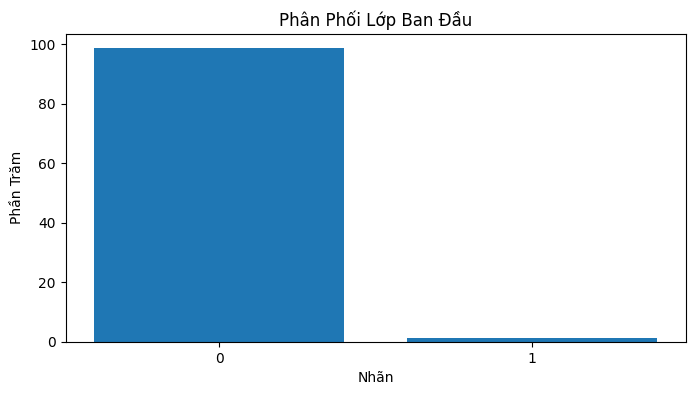


Phân phối dữ liệu Train+Validation:
Lớp 0: 26623 mẫu (98.66%)
Lớp 1: 362 mẫu (1.34%)


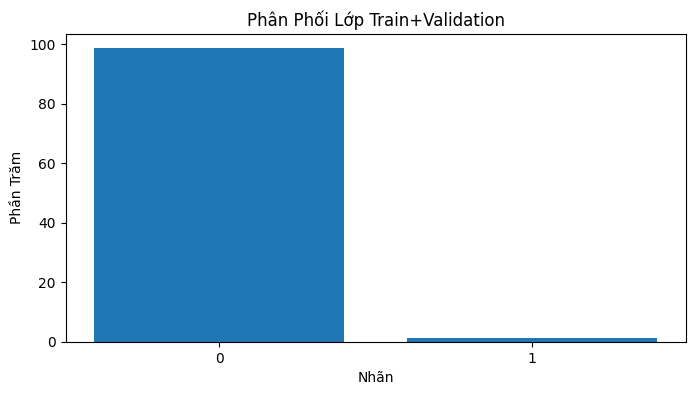


Phân phối dữ liệu Train:
Lớp 0: 19967 mẫu (98.66%)
Lớp 1: 271 mẫu (1.34%)


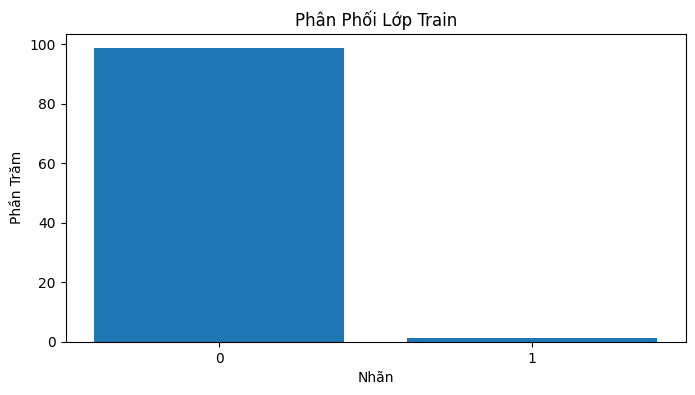


Phân phối dữ liệu Validation:
Lớp 0: 6656 mẫu (98.65%)
Lớp 1: 91 mẫu (1.35%)


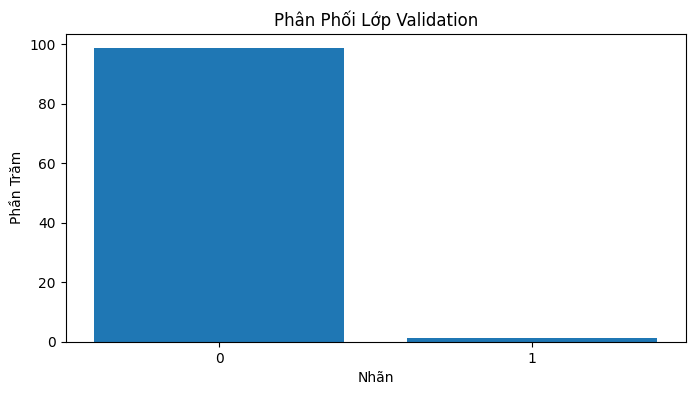


Phân phối dữ liệu Test:
Lớp 0: 6657 mẫu (98.67%)
Lớp 1: 90 mẫu (1.33%)


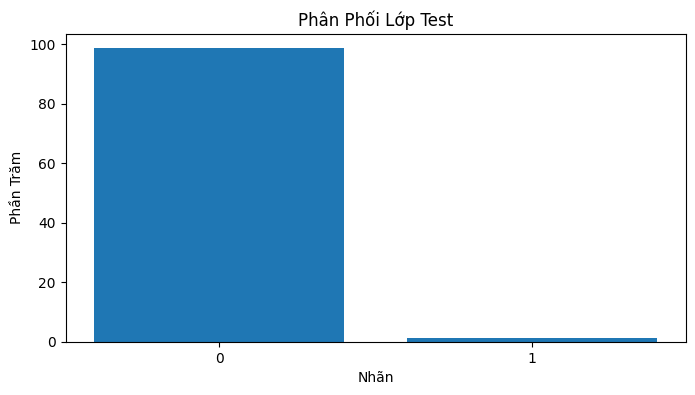


Kích thước các tập:
Train: (20238, 10)
Validation: (6747, 10)
Test: (6747, 10)


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def check_data_distribution(y, label=''):
    """Kiểm tra phân phối dữ liệu"""
    unique, counts = np.unique(y, return_counts=True)
    percentages = counts / len(y) * 100
    
    print(f"\nPhân phối dữ liệu {label}:")
    for value, count, percentage in zip(unique, counts, percentages):
        print(f"Lớp {value}: {count} mẫu ({percentage:.2f}%)")
    
    plt.figure(figsize=(8, 4))
    plt.bar(unique.astype(str), percentages)
    plt.title(f'Phân Phối Lớp {label}')
    plt.xlabel('Nhãn')
    plt.ylabel('Phần Trăm')
    plt.show()

def stratified_split_with_check(X, y, test_size=0.2, val_size=0.25, random_state=42):
    """
    Chia dữ liệu với kiểm tra phân phối chặt chẽ
    
    Parameters:
    - X: Ma trận đặc trưng
    - y: Nhãn
    - test_size: Tỷ lệ tập test
    - val_size: Tỷ lệ tập validation
    - random_state: Seed ngẫu nhiên
    
    Returns:
    - X_train, X_val, X_test
    - y_train, y_val, y_test
    """
    # Kiểm tra phân phối ban đầu
    check_data_distribution(y, 'Ban Đầu')
    
    # Chia tập test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=y  # Đảm bảo phân phối đều
    )
    
    # Kiểm tra phân phối train_val
    check_data_distribution(y_train_val, 'Train+Validation')
    
    # Chia tiếp train và validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, 
        test_size=val_size,  # Lưu ý: val_size là so với train_val
        random_state=random_state, 
        stratify=y_train_val  # Đảm bảo phân phối đều
    )
    
    # Kiểm tra phân phối của từng tập
    check_data_distribution(y_train, 'Train')
    check_data_distribution(y_val, 'Validation')
    check_data_distribution(y_test, 'Test')
    
    # In kích thước các tập (số hàng, số cột) 
    print("\nKích thước các tập:")
    print(f"Train: {X_train.shape}")
    print(f"Validation: {X_val.shape}")
    print(f"Test: {X_test.shape}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Sử dụng
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split_with_check(X, y)

## Trực quan hóa Đồ thị và Đặc trưng (Graph Visualizations)

Truy vấn mạng lưới gian lận dạng mẫu từ Neo4j...


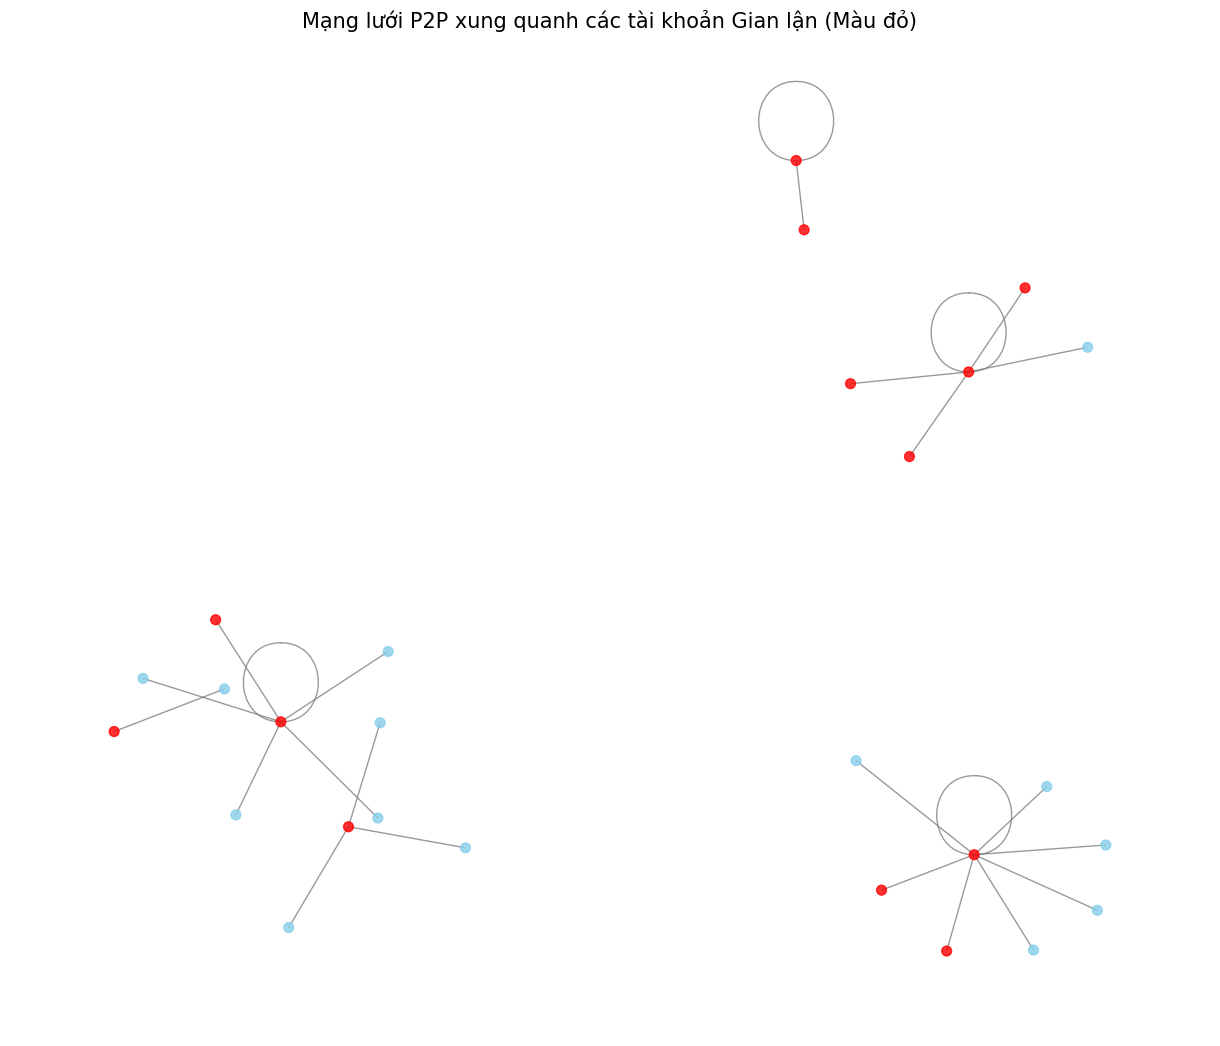

In [42]:
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

print("Truy vấn mạng lưới gian lận dạng mẫu từ Neo4j...")
# Tìm vài node có nhãn gian lận và lấy mạng lưới xung quanh nó (bán kính 2)
query = '''
MATCH p=(u1:User)-[r:P2P|SHARED_IDS*1..2]-(u2:User)
WHERE u1.fraudMoneyTransfer = 1 OR u1.fraudRisk = 1
RETURN u1.guid AS source, u2.guid AS target, type(r[0]) AS edge_type
LIMIT 300
'''
try:
    sub_edges = gds.run_cypher(query)
    
    # Khởi tạo đồ thị NetworkX
    G_vis = nx.from_pandas_edgelist(sub_edges, source='source', target='target', edge_attr='edge_type')
    
    plt.figure(figsize=(12, 10))
    # Phân loại màu: gian lận thì đỏ, bình thường thì xanh
    fraud_guids = set(df[(df['fraudMoneyTransfer'] == 1) | (df['fraudRisk'] == 1)]['guid'].values)
    
    color_map = []
    for node in G_vis.nodes():
        if node in fraud_guids:
            color_map.append('red')
        else:
            color_map.append('skyblue')
            
    pos = nx.spring_layout(G_vis, k=0.15, iterations=20, seed=42)
    nx.draw(G_vis, pos, node_size=50, node_color=color_map, edge_color='gray', with_labels=False, alpha=0.8)
    plt.title("Mạng lưới P2P xung quanh các tài khoản Gian lận (Màu đỏ)", fontsize=15)
    plt.show()
except Exception as e:
    print(f"Lỗi vẽ đồ thị NetworkX: {e}")

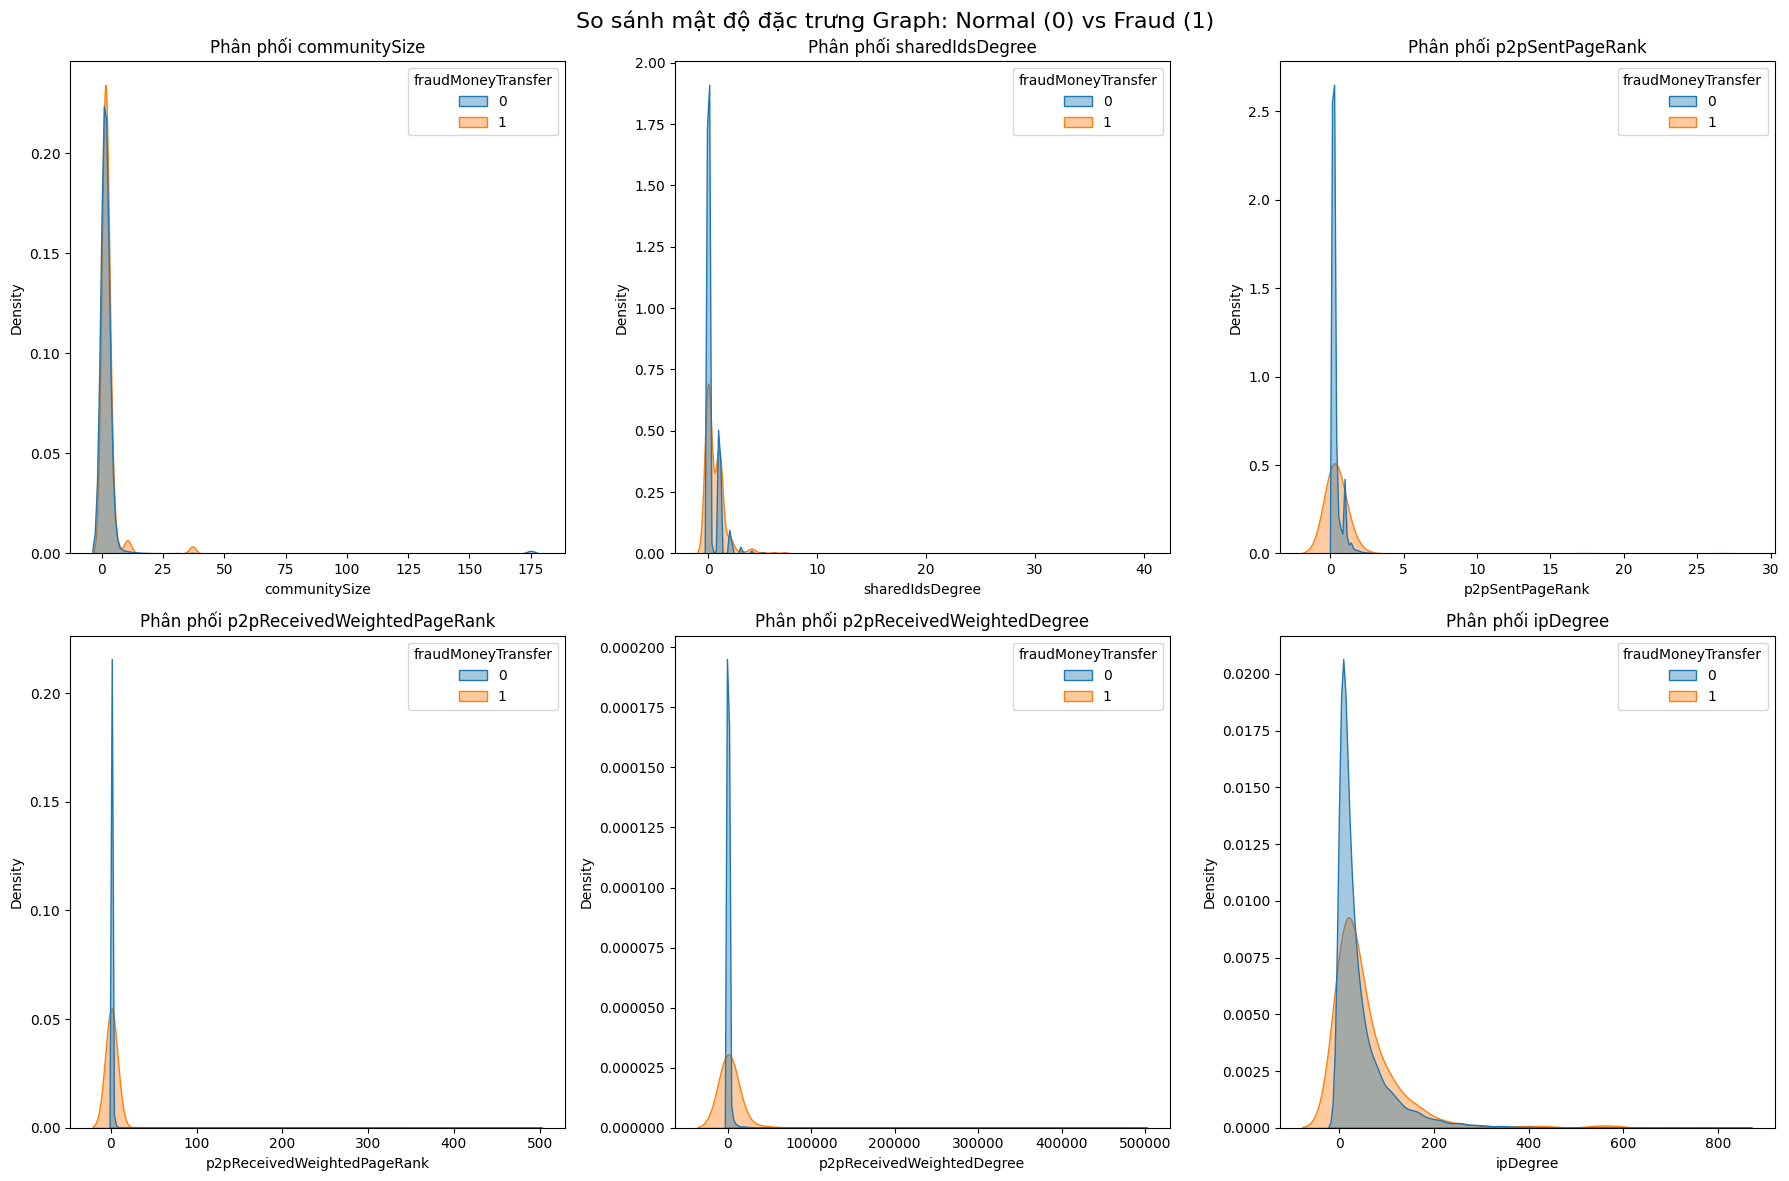

In [43]:
# Trực quan hóa phân phối của các Đặc trưng Đồ thị bằng KDE Plot
# Chọn lọc các features có ý nghĩa đồ thị
feature_cols = ['communitySize', 'sharedIdsDegree', 'p2pSentPageRank', 'p2pReceivedWeightedPageRank', 'p2pReceivedWeightedDegree', 'ipDegree']
feats_to_plot = [f for f in feature_cols if f in df.columns]

plt.figure(figsize=(18, 12))
for i, feat in enumerate(feats_to_plot):
    plt.subplot(2, 3, i+1)
    
    # Lưu ý: Các đồ thị Power-law như Degree/PageRank thường bị lệch trái siêu nặng
    sns.kdeplot(data=df, x=feat, hue='fraudMoneyTransfer', common_norm=False, fill=True, alpha=0.4, log_scale=(False, False))
    plt.title(f'Phân phối {feat}', fontsize=12)
    
plt.suptitle('So sánh mật độ đặc trưng Graph: Normal (0) vs Fraud (1)', fontsize=16)
plt.tight_layout()
plt.show()

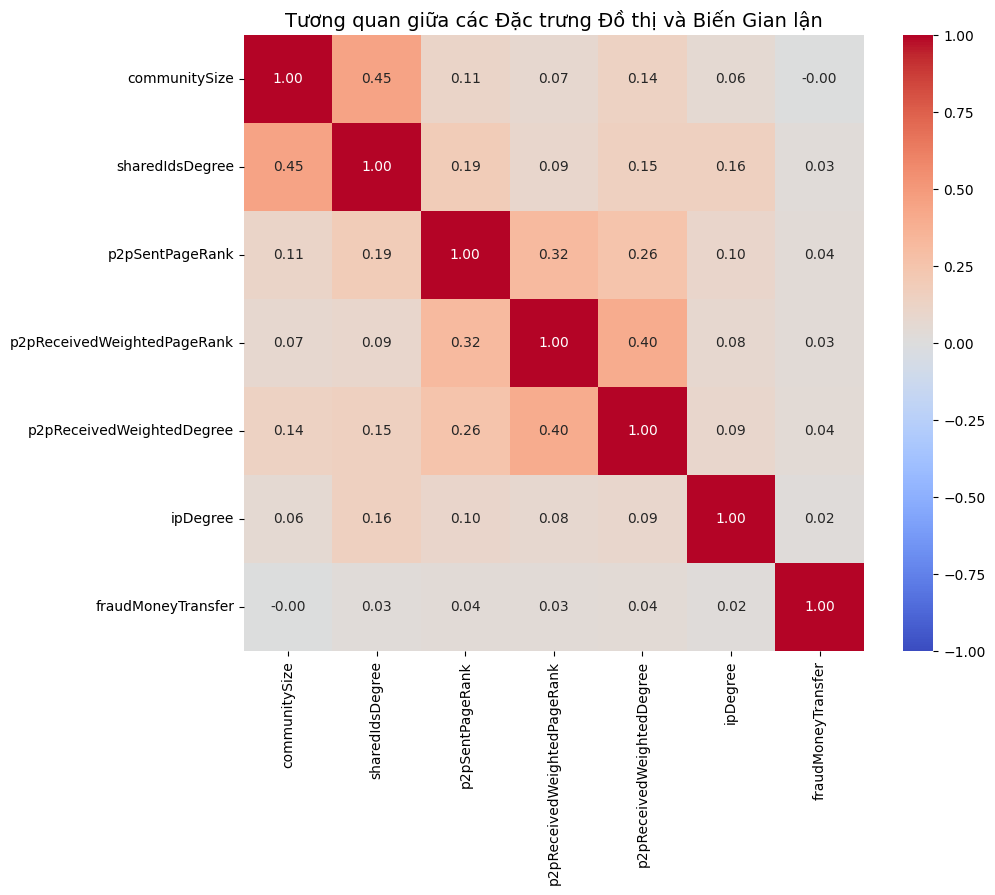

In [44]:
# Trực quan hóa Ma trận Tương quan (Correlation Heatmap) của Graph Features
plt.figure(figsize=(10, 8))
corr = df[feats_to_plot + ['fraudMoneyTransfer']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Tương quan giữa các Đặc trưng Đồ thị và Biến Gian lận", fontsize=14)
plt.show()

In [45]:
# Setup Phase 1: Models & Metrics
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score, precision_score
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def evaluate_model(model_name, y_true, y_pred, y_pred_proba=None):
    print(f"--- Evaluation for {model_name} ---")
    print(classification_report(y_true, y_pred, digits=4))
    res = {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score': round(f1_score(y_true, y_pred, zero_division=0), 4)
    }
    return res

results_baseline = []
results_weighted = []
results_smote = []
results_focal = []


### Giai đoạn 1.1: Trọng số gốc (Baseline Models)

In [46]:
# 1. Decision Tree (Base)
from sklearn.tree import DecisionTreeClassifier

print("Training Decision Tree...")
start = time.time()
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print(f"Training time: {time.time() - start:.2f}s")

y_pred_dt = dt.predict(X_test)
res_dt = evaluate_model("Decision Tree (Base)", y_test, y_pred_dt)
results_baseline.append(res_dt)

Training Decision Tree...
Training time: 0.09s
--- Evaluation for Decision Tree (Base) ---
              precision    recall  f1-score   support

           0     0.9890    0.9851    0.9871      6657
           1     0.1466    0.1889    0.1650        90

    accuracy                         0.9745      6747
   macro avg     0.5678    0.5870    0.5761      6747
weighted avg     0.9778    0.9745    0.9761      6747



In [47]:
# 2. Random Forest (Base)
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Training time: {time.time() - start:.2f}s")

y_pred_rf = rf.predict(X_test)
res_rf = evaluate_model("Random Forest (Base)", y_test, y_pred_rf)
results_baseline.append(res_rf)


Training Random Forest...
Training time: 0.35s
--- Evaluation for Random Forest (Base) ---
              precision    recall  f1-score   support

           0     0.9880    0.9995    0.9937      6657
           1     0.7500    0.1000    0.1765        90

    accuracy                         0.9876      6747
   macro avg     0.8690    0.5498    0.5851      6747
weighted avg     0.9848    0.9876    0.9828      6747



In [48]:
# 3. LightGBM (Base)
import lightgbm as lgb
import re

print("Training LightGBM...")
# Renaming features for LightGBM compatibility
X_train_lgb = X_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
X_test_lgb = X_test.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))

start = time.time()
lgbm = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
lgbm.fit(X_train_lgb, y_train)
print(f"Training time: {time.time() - start:.2f}s")

y_pred_lgbm = lgbm.predict(X_test_lgb)
res_lgbm = evaluate_model("LightGBM (Base)", y_test, y_pred_lgbm)
results_baseline.append(res_lgbm)


Training LightGBM...
[LightGBM] [Info] Number of positive: 271, number of negative: 19967
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000842 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1292
[LightGBM] [Info] Number of data points in the train set: 20238, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.013391 -> initscore=-4.299717
[LightGBM] [Info] Start training from score -4.299717
Training time: 0.12s
--- Evaluation for LightGBM (Base) ---
              precision    recall  f1-score   support

           0     0.9887    0.9994    0.9940      6657
           1     0.7778    0.1556    0.2593        90

    accuracy                         0.9881      6747
   macro avg     0.8832    0.5775    0.6266      6747
weighted avg     0.9859    0.9881    0.9842      6747



In [49]:
# 4. KNN (Base)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

print("Training KNN...")
# Cần scale data cho KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

start = time.time()
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_scaled, y_train)
print(f"Training time: {time.time() - start:.2f}s")

y_pred_knn = knn.predict(X_test_scaled)
res_knn = evaluate_model("KNN (Base)", y_test, y_pred_knn)
results_baseline.append(res_knn)


Training KNN...
Training time: 0.04s
--- Evaluation for KNN (Base) ---
              precision    recall  f1-score   support

           0     0.9874    0.9989    0.9931      6657
           1     0.4167    0.0556    0.0980        90

    accuracy                         0.9864      6747
   macro avg     0.7020    0.5273    0.5456      6747
weighted avg     0.9798    0.9864    0.9812      6747



In [50]:
# 5. Naive Bayes (Base)
from sklearn.naive_bayes import GaussianNB

print("Training Naive Bayes...")
start = time.time()
nb = GaussianNB()
nb.fit(X_train_scaled, y_train) # Dùng luôn data đã scaled để đồng nhất
print(f"Training time: {time.time() - start:.2f}s")

y_pred_nb = nb.predict(X_test_scaled)
res_nb = evaluate_model("Naive Bayes (Base)", y_test, y_pred_nb)
results_baseline.append(res_nb)


Training Naive Bayes...
Training time: 0.01s
--- Evaluation for Naive Bayes (Base) ---
              precision    recall  f1-score   support

           0     0.9876    0.9779    0.9827      6657
           1     0.0516    0.0889    0.0653        90

    accuracy                         0.9661      6747
   macro avg     0.5196    0.5334    0.5240      6747
weighted avg     0.9751    0.9661    0.9705      6747



In [51]:
# 6. Bagging Classifier (Base)
from sklearn.ensemble import BaggingClassifier

print("Training Bagging Classifier...")
start = time.time()
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=50, random_state=42, n_jobs=-1)
bagging.fit(X_train, y_train)
print(f"Training time: {time.time() - start:.2f}s")

y_pred_bagging = bagging.predict(X_test)
res_bagging = evaluate_model("Bagging (Base)", y_test, y_pred_bagging)
results_baseline.append(res_bagging)


Training Bagging Classifier...
Training time: 4.51s
--- Evaluation for Bagging (Base) ---
              precision    recall  f1-score   support

           0     0.9888    0.9988    0.9938      6657
           1     0.6522    0.1667    0.2655        90

    accuracy                         0.9877      6747
   macro avg     0.8205    0.5827    0.6296      6747
weighted avg     0.9844    0.9877    0.9841      6747



In [52]:
# 7. XGBoost (Base)
import xgboost as xgb

print("Training XGBoost...")
start = time.time()
xgb_cl = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_cl.fit(X_train, y_train)
print(f"Training time: {time.time() - start:.2f}s")

y_pred_xgb = xgb_cl.predict(X_test)
res_xgb = evaluate_model("XGBoost (Base)", y_test, y_pred_xgb)
results_baseline.append(res_xgb)


Training XGBoost...
Training time: 0.13s
--- Evaluation for XGBoost (Base) ---
              precision    recall  f1-score   support

           0     0.9887    0.9986    0.9936      6657
           1     0.6087    0.1556    0.2478        90

    accuracy                         0.9874      6747
   macro avg     0.7987    0.5771    0.6207      6747
weighted avg     0.9836    0.9874    0.9837      6747



In [53]:
# Đánh giá tổng quan Baseline Models
df_baseline = pd.DataFrame(results_baseline).sort_values(by='F1-Score', ascending=False)
display(df_baseline)


,Model,Accuracy,Precision,Recall,F1-Score
5,Bagging (Base),0.9877,0.6522,0.1667,0.2655
2,LightGBM (Base),0.9881,0.7778,0.1556,0.2593
6,XGBoost (Base),0.9874,0.6087,0.1556,0.2478
1,Random Forest (Base),0.9876,0.7500,0.1000,0.1765
0,Decision Tree (Base),0.9745,0.1466,0.1889,0.1650
3,KNN (Base),0.9864,0.4167,0.0556,0.0980
4,Naive Bayes (Base),0.9661,0.0516,0.0889,0.0653


### Giai đoạn 1.2: Các kỹ thuật xử lý Mất Cân Bằng
#### 1. Class Weighting

In [54]:
# Class Weighting - Decision Tree
print("Training Decision Tree (Class Weights)...")
dt_w = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_w.fit(X_train, y_train)
y_pred_dt_w = dt_w.predict(X_test)
res_dt_w = evaluate_model("Decision Tree (Weighted)", y_test, y_pred_dt_w)
results_weighted.append(res_dt_w)


Training Decision Tree (Class Weights)...
--- Evaluation for Decision Tree (Weighted) ---
              precision    recall  f1-score   support

           0     0.9893    0.9881    0.9887      6657
           1     0.1939    0.2111    0.2021        90

    accuracy                         0.9778      6747
   macro avg     0.5916    0.5996    0.5954      6747
weighted avg     0.9787    0.9778    0.9782      6747



In [55]:
# Class Weighting - Random Forest
print("Training Random Forest (Class Weights)...")
rf_w = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_w.fit(X_train, y_train)
y_pred_rf_w = rf_w.predict(X_test)
res_rf_w = evaluate_model("Random Forest (Weighted)", y_test, y_pred_rf_w)
results_weighted.append(res_rf_w)


Training Random Forest (Class Weights)...
--- Evaluation for Random Forest (Weighted) ---
              precision    recall  f1-score   support

           0     0.9872    0.9974    0.9923      6657
           1     0.1905    0.0444    0.0721        90

    accuracy                         0.9847      6747
   macro avg     0.5888    0.5209    0.5322      6747
weighted avg     0.9766    0.9847    0.9800      6747



In [56]:
# Class Weighting - LightGBM
print("Training LightGBM (Class Weights)...")
lgbm_w = lgb.LGBMClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
lgbm_w.fit(X_train_lgb, y_train)
y_pred_lgbm_w = lgbm_w.predict(X_test_lgb)
res_lgbm_w = evaluate_model("LightGBM (Weighted)", y_test, y_pred_lgbm_w)
results_weighted.append(res_lgbm_w)


Training LightGBM (Class Weights)...
[LightGBM] [Info] Number of positive: 271, number of negative: 19967
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1292
[LightGBM] [Info] Number of data points in the train set: 20238, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
--- Evaluation for LightGBM (Weighted) ---
              precision    recall  f1-score   support

           0     0.9933    0.9531    0.9728      6657
           1     0.1309    0.5222    0.2094        90

    accuracy                         0.9474      6747
   macro avg     0.5621    0.7377    0.5911      6747
weighted avg     0.9818    0.9474    0.9626      6747



In [57]:
# Class Weighting - Bagging Classifier
print("Training Bagging Classifier (Class Weights)...")
bagging_w = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42, class_weight='balanced'), n_estimators=50, random_state=42, n_jobs=-1)
bagging_w.fit(X_train, y_train)
y_pred_bagging_w = bagging_w.predict(X_test)
res_bagging_w = evaluate_model("Bagging (Weighted)", y_test, y_pred_bagging_w)
results_weighted.append(res_bagging_w)


Training Bagging Classifier (Class Weights)...
--- Evaluation for Bagging (Weighted) ---
              precision    recall  f1-score   support

           0     0.9884    0.9971    0.9927      6657
           1     0.3871    0.1333    0.1983        90

    accuracy                         0.9856      6747
   macro avg     0.6877    0.5652    0.5955      6747
weighted avg     0.9804    0.9856    0.9821      6747



In [ ]:
# Class Weighting - XGBoost
print("Training XGBoost (Class Weights)...")
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_cl_w = xgb.XGBClassifier(random_state=42, n_jobs=-1, scale_pos_weight=scale_pos_weight, eval_metric='logloss')
xgb_cl_w.fit(X_train, y_train)
y_pred_xgb_w = xgb_cl_w.predict(X_test)
res_xgb_w = evaluate_model("XGBoost (Weighted)", y_test, y_pred_xgb_w)
results_weighted.append(res_xgb_w)

Training XGBoost (Class Weights)...
--- Evaluation for XGBoost (Weighted) ---
              precision    recall  f1-score   support

           0     0.9904    0.9808    0.9856      6657
           1     0.1742    0.3000    0.2204        90

    accuracy                         0.9717      6747
   macro avg     0.5823    0.6404    0.6030      6747
weighted avg     0.9796    0.9717    0.9754      6747



In [59]:
# Đánh giá tổng quan Weighted Models
df_weighted = pd.DataFrame(results_weighted).sort_values(by='F1-Score', ascending=False)
display(df_weighted)


,Model,Accuracy,Precision,Recall,F1-Score
4,XGBoost (Weighted),0.9717,0.1742,0.3000,0.2204
2,LightGBM (Weighted),0.9474,0.1309,0.5222,0.2094
0,Decision Tree (Weighted),0.9778,0.1939,0.2111,0.2021
3,Bagging (Weighted),0.9856,0.3871,0.1333,0.1983
1,Random Forest (Weighted),0.9847,0.1905,0.0444,0.0721


#### 2. Kỹ thuật SMOTE (Oversampling)

In [60]:
# Áp dụng SMOTE
from imblearn.over_sampling import SMOTE

print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Chuẩn bị data cho các mô hình đặc thù
X_train_smote_lgb = X_train_smote.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_smote_scaled = scaler.transform(X_test) 

print("SMOTE distribution:", pd.Series(y_train_smote).value_counts().to_dict())


Applying SMOTE...
SMOTE distribution: {0: 19967, 1: 19967}


In [ ]:
# SMOTE - Decision Tree
print("Decision Tree (SMOTE)...")
dt_s = DecisionTreeClassifier(random_state=42)
dt_s.fit(X_train_smote, y_train_smote)
y_pred_dt_s = dt_s.predict(X_test)
res_dt_s = evaluate_model("Decision Tree (SMOTE)", y_test, y_pred_dt_s)
results_smote.append(res_dt_s)


--- Evaluation for Decision Tree (SMOTE) ---
              precision    recall  f1-score   support

           0     0.9888    0.9806    0.9847      6657
           1     0.1103    0.1778    0.1362        90

    accuracy                         0.9699      6747
   macro avg     0.5496    0.5792    0.5604      6747
weighted avg     0.9771    0.9699    0.9734      6747



In [ ]:
# SMOTE - Random Forest
print("Random Forest (SMOTE)...")
rf_s = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_s.fit(X_train_smote, y_train_smote)
y_pred_rf_s = rf_s.predict(X_test)
res_rf_s = evaluate_model("Random Forest (SMOTE)", y_test, y_pred_rf_s)
results_smote.append(res_rf_s)


--- Evaluation for Random Forest (SMOTE) ---
              precision    recall  f1-score   support

           0     0.9888    0.9941    0.9915      6657
           1     0.2778    0.1667    0.2083        90

    accuracy                         0.9831      6747
   macro avg     0.6333    0.5804    0.5999      6747
weighted avg     0.9793    0.9831    0.9810      6747



In [ ]:
# SMOTE - LightGBM
print("LightGBM (SMOTE)...")
lgbm_s = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
lgbm_s.fit(X_train_smote_lgb, y_train_smote)
y_pred_lgbm_s = lgbm_s.predict(X_test_lgb)
res_lgbm_s = evaluate_model("LightGBM (SMOTE)", y_test, y_pred_lgbm_s)
results_smote.append(res_lgbm_s)


[LightGBM] [Info] Number of positive: 19967, number of negative: 19967
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000552 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2081
[LightGBM] [Info] Number of data points in the train set: 39934, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
--- Evaluation for LightGBM (SMOTE) ---
              precision    recall  f1-score   support

           0     0.9892    0.9943    0.9918      6657
           1     0.3214    0.2000    0.2466        90

    accuracy                         0.9837      6747
   macro avg     0.6553    0.5971    0.6192      6747
weighted avg     0.9803    0.9837    0.9818      6747



In [ ]:
# SMOTE - KNN
print("KNN (SMOTE)...")
knn_s = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_s.fit(X_train_smote_scaled, y_train_smote)
y_pred_knn_s = knn_s.predict(X_test_smote_scaled)
res_knn_s = evaluate_model("KNN (SMOTE)", y_test, y_pred_knn_s)
results_smote.append(res_knn_s)


--- Evaluation for KNN (SMOTE) ---
              precision    recall  f1-score   support

           0     0.9917    0.9470    0.9688      6657
           1     0.0949    0.4111    0.1542        90

    accuracy                         0.9398      6747
   macro avg     0.5433    0.6790    0.5615      6747
weighted avg     0.9797    0.9398    0.9579      6747



In [ ]:
# SMOTE - Naive Bayes
print("Naive Bayes (SMOTE)...")
nb_s = GaussianNB()
nb_s.fit(X_train_smote_scaled, y_train_smote)
y_pred_nb_s = nb_s.predict(X_test_smote_scaled)
res_nb_s = evaluate_model("Naive Bayes (SMOTE)", y_test, y_pred_nb_s)
results_smote.append(res_nb_s)

--- Evaluation for Naive Bayes (SMOTE) ---
              precision    recall  f1-score   support

           0     0.9875    0.9641    0.9757      6657
           1     0.0363    0.1000    0.0533        90

    accuracy                         0.9526      6747
   macro avg     0.5119    0.5320    0.5145      6747
weighted avg     0.9748    0.9526    0.9634      6747



In [ ]:
# SMOTE - Bagging
print("Bagging (SMOTE)...")
bagging_s = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=50, random_state=42, n_jobs=-1)
bagging_s.fit(X_train_smote, y_train_smote)
y_pred_bagging_s = bagging_s.predict(X_test)
res_bagging_s = evaluate_model("Bagging (SMOTE)", y_test, y_pred_bagging_s)
results_smote.append(res_bagging_s)


--- Evaluation for Bagging (SMOTE) ---
              precision    recall  f1-score   support

           0     0.9885    0.9901    0.9893      6657
           1     0.1646    0.1444    0.1538        90

    accuracy                         0.9788      6747
   macro avg     0.5765    0.5673    0.5716      6747
weighted avg     0.9775    0.9788    0.9781      6747



In [ ]:
# SMOTE - XGBoost
print("XGBoost (SMOTE)...")
xgb_cl_s = xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_cl_s.fit(X_train_smote, y_train_smote)
y_pred_xgb_s = xgb_cl_s.predict(X_test)
res_xgb_s = evaluate_model("XGBoost (SMOTE)", y_test, y_pred_xgb_s)
results_smote.append(res_xgb_s)


--- Evaluation for XGBoost (SMOTE) ---
              precision    recall  f1-score   support

           0     0.9889    0.9938    0.9914      6657
           1     0.2807    0.1778    0.2177        90

    accuracy                         0.9830      6747
   macro avg     0.6348    0.5858    0.6045      6747
weighted avg     0.9795    0.9830    0.9811      6747



In [68]:
# Đánh giá tổng quan SMOTE Models
df_smote = pd.DataFrame(results_smote).sort_values(by='F1-Score', ascending=False)
display(df_smote)


,Model,Accuracy,Precision,Recall,F1-Score
2,LightGBM (SMOTE),0.9837,0.3214,0.2000,0.2466
6,XGBoost (SMOTE),0.9830,0.2807,0.1778,0.2177
1,Random Forest (SMOTE),0.9831,0.2778,0.1667,0.2083
3,KNN (SMOTE),0.9398,0.0949,0.4111,0.1542
5,Bagging (SMOTE),0.9788,0.1646,0.1444,0.1538
0,Decision Tree (SMOTE),0.9699,0.1103,0.1778,0.1362
4,Naive Bayes (SMOTE),0.9526,0.0363,0.1000,0.0533


#### 3. Kỹ thuật Focal Loss (Cho XGBoost & LightGBM)

In [69]:
# Định nghĩa Focal Loss
import numpy as np

# Focal loss cho LightGBM
def focal_loss_lgb(y_pred, dtrain):
    y_true = dtrain.get_label()
    a = 0.25
    g = 2.0
    p = 1 / (1 + np.exp(-y_pred))
    
    grad = -(a*y_true*(1-p)**g * (1 - p - g*p*np.log(np.maximum(p, 1e-9))) - (1-a)*(1-y_true)*p**g * (p + g*(1-p)*np.log(np.maximum(1-p, 1e-9))))
    p_hess = np.maximum(p, 1e-5)
    hess = p_hess * (1 - p_hess) 
    return grad, hess

def focal_loss_eval_lgb(y_pred, dtrain):
    y_true = dtrain.get_label()
    a = 0.25
    g = 2.0
    p = 1 / (1 + np.exp(-y_pred))
    p = np.clip(p, 1e-9, 1-1e-9)
    loss = -a * y_true * ((1-p)**g) * np.log(p) - (1-a) * (1-y_true) * (p**g) * np.log(1-p)
    return 'focal_loss', np.mean(loss), False

# Focal loss cho XGBoost
def focal_loss_xgb(predt: np.ndarray, dtrain: xgb.DMatrix):
    y_true = dtrain.get_label()
    a = 0.25
    g = 2.0
    p = 1 / (1 + np.exp(-predt))
    grad = -(a*y_true*(1-p)**g * (1 - p - g*p*np.log(np.maximum(p, 1e-9))) - (1-a)*(1-y_true)*p**g * (p + g*(1-p)*np.log(np.maximum(1-p, 1e-9))))
    hess = p * (1 - p) * 10 
    return grad, hess


In [70]:
# Focal Loss - LightGBM
print("Training LightGBM (Focal Loss)...")
import lightgbm as lgb
train_data_lgb = lgb.Dataset(X_train_lgb, label=y_train)
val_data_lgb = lgb.Dataset(X_val.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x)), label=y_val)

params = {
    'learning_rate': 0.1,
    'num_leaves': 31,
    'objective': focal_loss_lgb,
    'verbose': -1,
    'random_state': 42
}

lgbm_focal = lgb.train(
    params,
    train_data_lgb,
    feval=focal_loss_eval_lgb,
    num_boost_round=100,
    valid_sets=[train_data_lgb, val_data_lgb]
)

y_pred_lgbm_focal_raw = lgbm_focal.predict(X_test_lgb)
y_pred_lgbm_focal = (1 / (1 + np.exp(-y_pred_lgbm_focal_raw)) > 0.5).astype(int)
res_lgbm_f = evaluate_model("LightGBM (Focal Loss)", y_test, y_pred_lgbm_focal)
results_focal.append(res_lgbm_f)


Training LightGBM (Focal Loss)...
--- Evaluation for LightGBM (Focal Loss) ---
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      6657
           1     0.0133    1.0000    0.0263        90

    accuracy                         0.0133      6747
   macro avg     0.0067    0.5000    0.0132      6747
weighted avg     0.0002    0.0133    0.0004      6747



In [71]:
# Focal Loss - XGBoost
print("Training XGBoost (Focal Loss)...")
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test)

params_xgb = {
    'learning_rate': 0.1,
    'max_depth': 6,
    'disable_default_eval_metric': 1,
    'random_state': 42
}

xgb_focal = xgb.train(
    params_xgb,
    dtrain,
    num_boost_round=100,
    obj=focal_loss_xgb,
    evals=[(dtrain, 'train'), (dval, 'val')],
    verbose_eval=False
)

y_pred_xgb_focal_raw = xgb_focal.predict(dtest)
y_pred_xgb_focal = (1 / (1 + np.exp(-y_pred_xgb_focal_raw)) > 0.5).astype(int)
res_xgb_f = evaluate_model("XGBoost (Focal Loss)", y_test, y_pred_xgb_focal)
results_focal.append(res_xgb_f)


Training XGBoost (Focal Loss)...
--- Evaluation for XGBoost (Focal Loss) ---
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      6657
           1     0.0133    1.0000    0.0263        90

    accuracy                         0.0133      6747
   macro avg     0.0067    0.5000    0.0132      6747
weighted avg     0.0002    0.0133    0.0004      6747



In [72]:
# Đánh giá tổng quan Focal Loss Models
df_focal = pd.DataFrame(results_focal).sort_values(by='F1-Score', ascending=False)
display(df_focal)


,Model,Accuracy,Precision,Recall,F1-Score
0,LightGBM (Focal Loss),0.0133,0.0133,1.0,0.0263
1,XGBoost (Focal Loss),0.0133,0.0133,1.0,0.0263


## Giai đoạn 2: Khai thác Cấu trúc Đồ thị bằng GNN (PyTorch Geometric)

In [73]:
# Chuẩn bị dữ liệu cho GNN
import torch
import torch.nn.functional as F
try:
    from torch_geometric.data import Data
    from torch_geometric.transforms import ToUndirected
    from torch_geometric.nn import SAGEConv
except ImportError:
    print("Vui lòng cài đặt (mở terminal): pip install torch-geometric")
    print("Nếu lỗi liên quan đến pytorch-scatter, cài theo instruction trên: https://pytorch-geometric.readthedocs.io/en/latest/notes/installation.html")

print(f"PyTorch version: {torch.__version__}")


PyTorch version: 2.10.0+cpu


In [74]:
# Kết xuất Edge Index từ Neo4j để xây dựng PyTorch Geometric Data
print("Kết xuất dữ liệu từ Neo4j...")
# Lấy danh sách guid và map thành index 0 -> N-1 theo chỉ số dòng (index) của X
df_nodes = X.copy()
df_nodes['guid'] = df['guid'] # do X là lấy từ df
node_mapping = {guid: i for guid, i in zip(df_nodes['guid'], df_nodes.index)}

# Truy vấn P2P edges
query_p2p = '''
MATCH (u1:User)-[r:P2P]->(u2:User)
RETURN u1.guid AS source_guid, u2.guid AS target_guid
'''
edges_p2p_df = gds.run_cypher(query_p2p)

# Truy vấn SHARED_IDS edges 
query_shared = '''
MATCH (u1:User)-[r:SHARED_IDS]->(u2:User)
RETURN u1.guid AS source_guid, u2.guid AS target_guid
'''
edges_shared_df = gds.run_cypher(query_shared)

# Ánh xạ guid thành index
edges_p2p_mapped = edges_p2p_df.copy()
edges_p2p_mapped['source_guid'] = edges_p2p_mapped['source_guid'].map(node_mapping)
edges_p2p_mapped['target_guid'] = edges_p2p_mapped['target_guid'].map(node_mapping)
edges_p2p_mapped.dropna(inplace=True)

edges_shared_mapped = edges_shared_df.copy()
edges_shared_mapped['source_guid'] = edges_shared_mapped['source_guid'].map(node_mapping)
edges_shared_mapped['target_guid'] = edges_shared_mapped['target_guid'].map(node_mapping)
edges_shared_mapped.dropna(inplace=True)

# Tạo tensor cho Edge Index P2P và SHARED
edge_index_p2p = torch.tensor([edges_p2p_mapped['source_guid'].values, edges_p2p_mapped['target_guid'].values], dtype=torch.long)
edge_index_shared = torch.tensor([edges_shared_mapped['source_guid'].values, edges_shared_mapped['target_guid'].values], dtype=torch.long)

# Gộp edges (Multigraph -> Unigraph đơn nguyên dể GraphSAGE dễ chạy hơn)
edge_index_combined = torch.cat([edge_index_p2p, edge_index_shared], dim=1)
edge_index_combined = torch.unique(edge_index_combined, dim=1)

print(f"Tổng số cạnh liên kết (Edges): {edge_index_combined.shape[1]}")


Kết xuất dữ liệu từ Neo4j...
Tổng số cạnh liên kết (Edges): 45683


In [75]:
# Khởi tạo mô hình Pytorch Geometric Data Node Classification
X_tensor = torch.tensor(scaler.transform(X), dtype=torch.float) # Sử dụng Standard Scaler đã fit từ tập train
y_tensor = torch.tensor(y.values, dtype=torch.long)

data = Data(x=X_tensor, y=y_tensor, edge_index=edge_index_combined)
data = ToUndirected()(data)

# Chỉ định mask tập Train / Val / Test từ kết quả hàm stratified splitter
train_idx = X_train.index
val_idx = X_val.index
test_idx = X_test.index

data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.train_mask[train_idx.values] = True

data.val_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.val_mask[val_idx.values] = True

data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask[test_idx.values] = True

print(data)


Data(x=[33732, 10], edge_index=[2, 70414], y=[33732], train_mask=[33732], val_mask=[33732], test_mask=[33732])


In [76]:
# Xây dựng kiến trúc mô hình GNN (Nâng cao với GAT, Residual và BatchNorm)
try:
    from torch_geometric.nn import SAGEConv, GATConv
except ImportError:
    pass
import torch.nn as nn
import torch.nn.functional as F

class GraphFraudDetector(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GraphFraudDetector, self).__init__()
        
        # 1. Feature Extractor (MLP) cho raw tabular features
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, hidden_channels * 2),
            nn.BatchNorm1d(hidden_channels * 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU()
        )
        
        # 2. Graph Layers (GAT + SAGE)
        self.conv1 = GATConv(hidden_channels, hidden_channels, heads=4, concat=False)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        
        # 3. Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.BatchNorm1d(hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_channels // 2, out_channels)
        )

    def forward(self, x, edge_index):
        # Biểu diễn Tabular Node
        x = self.mlp(x)
        
        # Lớp GNN 1 (GAT) với Residual
        identity = x
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = x + identity # Residual connection
        
        # Lớp GNN 2 (SAGE) với Residual
        identity = x
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = x + identity
        
        # Đầu ra
        out = self.classifier(x)
        return out

model = GraphFraudDetector(data.num_node_features, 64, 2)
print(model)

GraphFraudDetector(
  (mlp): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
  )
  (conv1): GATConv(64, 64, heads=4)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): SAGEConv(64, 64, aggr=mean)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [77]:
# GNN sử dụng kỹ thuật Class Weighting (Nâng cao)
from sklearn.utils.class_weight import compute_class_weight
import torch

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weight_tensor = torch.tensor(class_weights, dtype=torch.float)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4) # Dùng AdamW tốt hơn Adam
criterion = torch.nn.CrossEntropyLoss(weight=weight_tensor)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=300) # Thêm LR Scheduler

def train_gnn():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    
    # Cắt gradient để tránh nổ
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()
    scheduler.step()
    return loss.item()

def eval_gnn(mask):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        loss = criterion(out[mask], data.y[mask])
        
        y_true_eval = data.y[mask].numpy()
        y_pred_eval = pred[mask].numpy()
        
        f1 = f1_score(y_true_eval, y_pred_eval, zero_division=0)
    return loss.item(), f1, y_true_eval, y_pred_eval

print("Bắt đầu huấn luyện GNN nâng cao...")
best_val_f1 = 0
best_model_state = None

for epoch in range(1, 1001): # Tăng epoch lên 300
    loss = train_gnn()
    val_loss, val_f1, _, _ = eval_gnn(data.val_mask)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_state = model.state_dict().copy()
    if epoch % 50 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}')

# Test bằng mô hình tốt nhất
model.load_state_dict(best_model_state)
test_loss, test_f1, y_true_gnn, y_pred_gnn = eval_gnn(data.test_mask)
res_gnn = evaluate_model("GNN Advanced (Class Weighted)", y_true_gnn, y_pred_gnn)
print(f"GNN Advanced Test F1: {test_f1:.4f}")

Bắt đầu huấn luyện GNN nâng cao...


Epoch: 050, Loss: 0.3145, Val Loss: 0.5214, Val F1: 0.1071, LR: 0.004665
Epoch: 100, Loss: 0.1635, Val Loss: 0.8359, Val F1: 0.1989, LR: 0.003750
Epoch: 150, Loss: 0.1072, Val Loss: 0.9774, Val F1: 0.2092, LR: 0.002500
Epoch: 200, Loss: 0.0763, Val Loss: 1.2170, Val F1: 0.2873, LR: 0.001250
Epoch: 250, Loss: 0.0770, Val Loss: 1.2667, Val F1: 0.3029, LR: 0.000335
Epoch: 300, Loss: 0.0772, Val Loss: 1.3050, Val F1: 0.2931, LR: 0.000000
Epoch: 350, Loss: 0.0658, Val Loss: 1.2897, Val F1: 0.2865, LR: 0.000335
Epoch: 400, Loss: 0.0639, Val Loss: 1.3723, Val F1: 0.2537, LR: 0.001250
Epoch: 450, Loss: 0.0559, Val Loss: 1.4936, Val F1: 0.2745, LR: 0.002500
Epoch: 500, Loss: 0.0769, Val Loss: 1.2900, Val F1: 0.1760, LR: 0.003750
Epoch: 550, Loss: 0.0645, Val Loss: 1.8483, Val F1: 0.3087, LR: 0.004665
Epoch: 600, Loss: 0.0445, Val Loss: 1.8741, Val F1: 0.3429, LR: 0.005000
Epoch: 650, Loss: 0.0460, Val Loss: 1.9919, Val F1: 0.3333, LR: 0.004665
Epoch: 700, Loss: 0.0551, Val Loss: 2.5343, Val F1:

In [78]:
# GNN sử dụng kỹ thuật Focal Loss (Nâng cao)
class FocalLossBinary(torch.nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0): # Chỉnh alpha cao hơn cho fraud
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = torch.nn.BCEWithLogitsLoss(reduction='none')
        
    def forward(self, inputs, targets):
        inputs_1 = inputs[:, 1] - inputs[:, 0]
        targets_bce = targets.float()
        
        bce_loss = self.bce(inputs_1, targets_bce)
        pt = torch.exp(-bce_loss) 
        
        alpha_t = targets_bce * self.alpha + (1 - targets_bce) * (1 - self.alpha)
        focal_loss = alpha_t * (1-pt)**self.gamma * bce_loss
        return focal_loss.mean()

criterion_focal = FocalLossBinary(alpha=0.8, gamma=2.0) 
model_focal = GraphFraudDetector(data.num_node_features, 64, 2)

optimizer_focal = torch.optim.AdamW(model_focal.parameters(), lr=0.005, weight_decay=1e-4)
scheduler_focal = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_focal, T_max=300)

def train_focal_gnn():
    model_focal.train()
    optimizer_focal.zero_grad()
    out = model_focal(data.x, data.edge_index)
    loss = criterion_focal(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_focal.parameters(), max_norm=1.0)
    optimizer_focal.step()
    scheduler_focal.step()
    return loss.item()

def eval_focal_gnn(mask):
    model_focal.eval()
    with torch.no_grad():
        out = model_focal(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        loss = criterion_focal(out[mask], data.y[mask])
        y_true_eval = data.y[mask].numpy()
        y_pred_eval = pred[mask].numpy()
        f1 = f1_score(y_true_eval, y_pred_eval, zero_division=0)
    return loss.item(), f1, y_true_eval, y_pred_eval

print("Bắt đầu huấn luyện GNN nâng cao với Focal Loss...")
best_val_f1_focal = 0
best_model_focal_state = None

for epoch in range(1, 1001):
    loss = train_focal_gnn()
    val_loss, val_f1, _, _ = eval_focal_gnn(data.val_mask)
    if val_f1 > best_val_f1_focal:
        best_val_f1_focal = val_f1
        best_model_focal_state = model_focal.state_dict().copy()
        
    if epoch % 50 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}')

model_focal.load_state_dict(best_model_focal_state)
test_loss_focal, test_f1_focal, y_true_gnn_f, y_pred_gnn_f = eval_focal_gnn(data.test_mask)
res_gnn_focal = evaluate_model("GNN Advanced (Focal Loss)", y_true_gnn_f, y_pred_gnn_f)
print(f"GNN Advanced (Focal) Test F1: {test_f1_focal:.4f}")

Bắt đầu huấn luyện GNN nâng cao với Focal Loss...
Epoch: 050, Loss: 0.0081, Val Loss: 0.0095, Val F1: 0.0404
Epoch: 100, Loss: 0.0065, Val Loss: 0.0096, Val F1: 0.0777
Epoch: 150, Loss: 0.0051, Val Loss: 0.0111, Val F1: 0.2615
Epoch: 200, Loss: 0.0042, Val Loss: 0.0118, Val F1: 0.3667
Epoch: 250, Loss: 0.0035, Val Loss: 0.0122, Val F1: 0.3793
Epoch: 300, Loss: 0.0033, Val Loss: 0.0124, Val F1: 0.3667
Epoch: 350, Loss: 0.0032, Val Loss: 0.0123, Val F1: 0.3687
Epoch: 400, Loss: 0.0031, Val Loss: 0.0142, Val F1: 0.3774
Epoch: 450, Loss: 0.0041, Val Loss: 0.0152, Val F1: 0.3931
Epoch: 500, Loss: 0.0026, Val Loss: 0.0200, Val F1: 0.4052
Epoch: 550, Loss: 0.0017, Val Loss: 0.0208, Val F1: 0.3899
Epoch: 600, Loss: 0.0016, Val Loss: 0.0213, Val F1: 0.3509
Epoch: 650, Loss: 0.0010, Val Loss: 0.0242, Val F1: 0.3977
Epoch: 700, Loss: 0.0009, Val Loss: 0.0296, Val F1: 0.3974
Epoch: 750, Loss: 0.0007, Val Loss: 0.0300, Val F1: 0.4294
Epoch: 800, Loss: 0.0006, Val Loss: 0.0306, Val F1: 0.4364
Epoch:

========= BẢNG SO SÁNH TỔNG HỢP (CẬP NHẬT GNN NÂNG CAO) =========


,Model,Accuracy,Precision,Recall,F1-Score
22,GNN Advanced (Focal Loss),0.9874,0.5373,0.4000,0.4586
21,GNN Advanced (Class Weighted),0.9801,0.3406,0.5222,0.4123
5,Bagging (Base),0.9877,0.6522,0.1667,0.2655
2,LightGBM (Base),0.9881,0.7778,0.1556,0.2593
6,XGBoost (Base),0.9874,0.6087,0.1556,0.2478
14,LightGBM (SMOTE),0.9837,0.3214,0.2000,0.2466
11,XGBoost (Weighted),0.9717,0.1742,0.3000,0.2204
18,XGBoost (SMOTE),0.9830,0.2807,0.1778,0.2177
9,LightGBM (Weighted),0.9474,0.1309,0.5222,0.2094
13,Random Forest (SMOTE),0.9831,0.2778,0.1667,0.2083


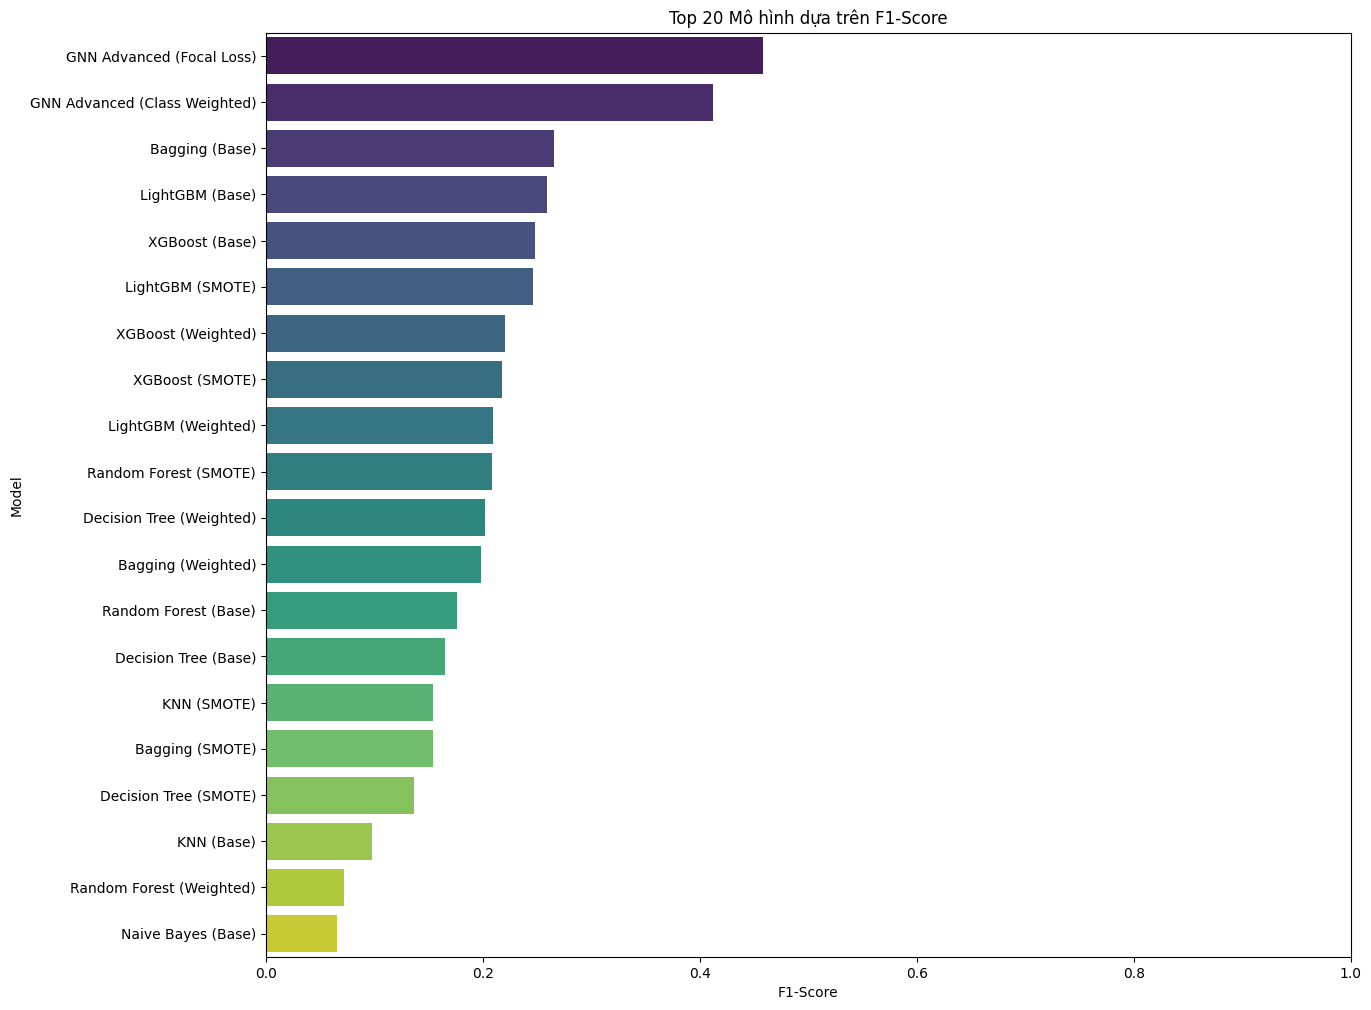

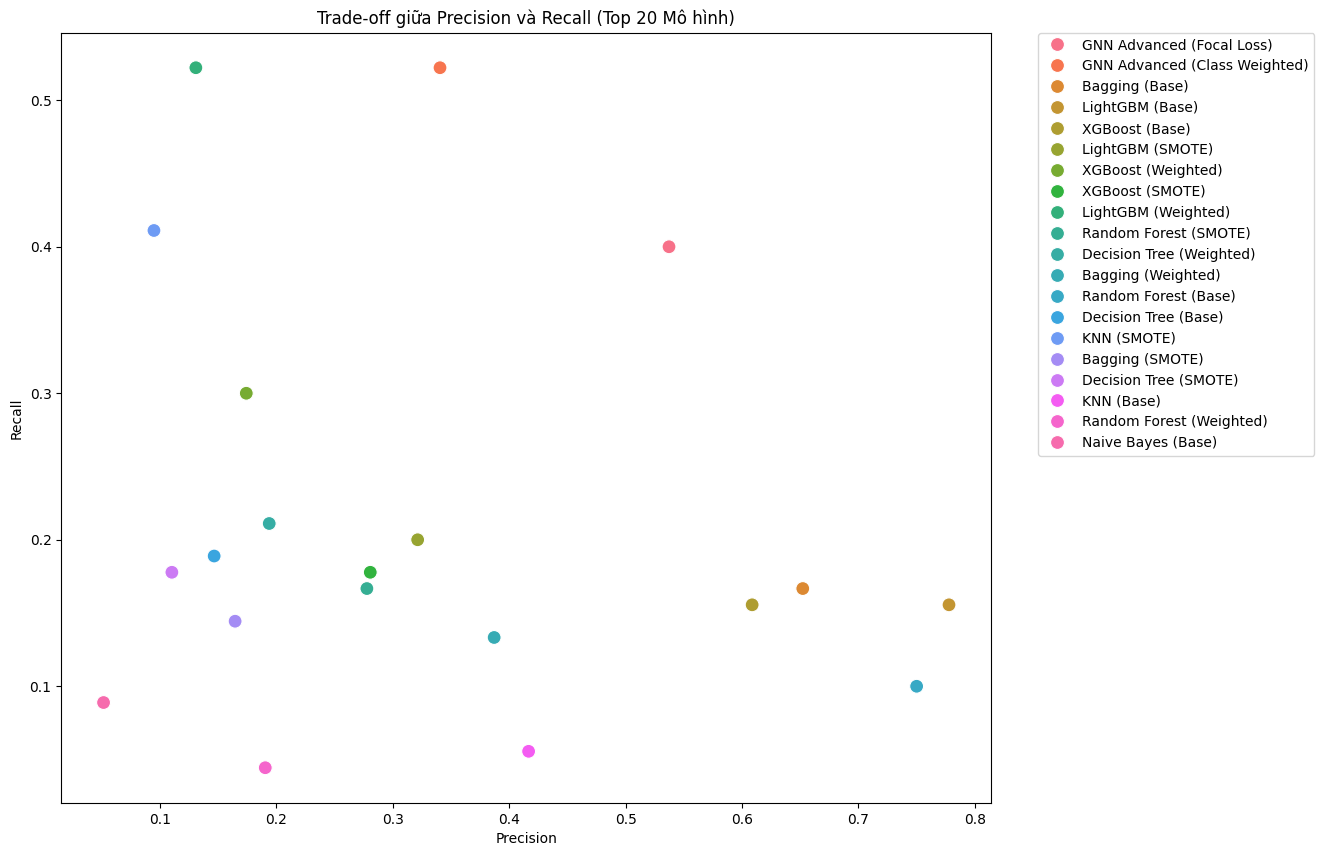

In [79]:
# TỔNG KẾT VÀ SO SÁNH TẤT CẢ CÁC MÔ HÌNH VÀ KỸ THUẬT
all_results = results_baseline + results_weighted + results_smote + results_focal + [res_gnn, res_gnn_focal]
df_all = pd.DataFrame(all_results).sort_values(by='F1-Score', ascending=False)

print("========= BẢNG SO SÁNH TỔNG HỢP (CẬP NHẬT GNN NÂNG CAO) =========")
display(df_all.head(20))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 12))
sns.barplot(data=df_all.head(20), x='F1-Score', y='Model', palette='viridis')
plt.title('Top 20 Mô hình dựa trên F1-Score')
plt.xlim(0, 1)
plt.show()

# Biểu đồ Recall vs Precision 
plt.figure(figsize=(12, 10))
sns.scatterplot(data=df_all.head(20), x='Precision', y='Recall', hue='Model', s=100)
plt.title('Trade-off giữa Precision và Recall (Top 20 Mô hình)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()